# YOLOv26 Semantic + Final 3-Model Comparison — LiTS (Notebook 3 of 4)

**Course:** CSE 348 Digital Image Processing — Assignment Part 1  
**Group:** 01  
**Department of Computer Science and Engineering, East West University**

**Group members:**
1. Md. Asif Hossain — 2022-3-60-007
2. Nabil Subhan — 2022-3-60-063
3. K M Nudar — 2022-3-60-234

Loads the **identical split** from NB0 → converts it to the YOLO semantic format → **Task E** (train ≥50 epochs) → **Task F** → **Task G** → **Task H** (final 3-model comparison, merging NB1 + NB2 metrics from `results.json`).

- **Model:** Ultralytics `yolo26s-sem.pt` (semantic `-sem`, **not** `-seg`).
- **Input:** 2.5D PNGs (channels = adjacent slices); tumor-slice oversampling (4×); YOLO flips on, colour-jitter off.
- **Mask format YOLO expects:** single-channel PNG, **pixel = class id**, **255 = ignore** — we export our fused `{0,1,2}` labels accordingly.
- **Metrics:** the **same confusion-matrix code** as NB1/NB2 for a fair comparison.

> **Setup on Kaggle:** Accelerator = **GPU T4 ×2**, Internet = **ON**. **+ Add Input:** LiTS dataset, **NB0 output** (`split.json`), **NB1 output** + **NB2 output** (their `best.pt` + `results.json`, needed for the Task H side-by-side comparison).

In [1]:
# =====================================================================
# 1. Setup & imports (version pins)  -- ensure ultralytics supports yolo26-sem
# =====================================================================
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "ultralytics"], check=False)

import os, re, json, time, glob, random, shutil, yaml
from pathlib import Path
import numpy as np, pandas as pd, cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
import ultralytics
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORK = Path("/kaggle/working"); WORK.mkdir(parents=True, exist_ok=True)
print("device:", device, "| GPUs:", torch.cuda.device_count())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.87 | torch 2.10.0+cu128
device: cuda | GPUs: 2


## 2. Load the shared split from NB0

In [2]:
# =====================================================================
# 2. Load split.json (from NB0) + rebuild path lookups
# =====================================================================
cand = glob.glob("/kaggle/input/**/split.json", recursive=True)
assert cand, "split.json not found -> + Add Input the NB0-output dataset."
meta = json.load(open(cand[0]))
CLASS_NAMES = meta["class_names"]; NUM_CLASSES = meta["num_classes"]; IMG_SIZE = 256
print("loaded split | seed", meta["seed"], "| filter_to_liver", meta["filter_to_liver"])

IMG_DIR, LIVER_DIR, TUMOR_DIR = (Path(meta["dirs"][k]) for k in ("images","liver","tumor"))
if not IMG_DIR.exists():
    root = Path(next(iter(glob.glob("/kaggle/input/**/Thesis_data", recursive=True))))
    IMG_DIR   = next(p for p in root.iterdir() if p.is_dir() and "image" in p.name.lower())
    LIVER_DIR = next(p for p in root.iterdir() if p.is_dir() and "liver" in p.name.lower())
    TUMOR_DIR = next(p for p in root.iterdir() if p.is_dir() and "tumor" in p.name.lower())

def vskey(p):
    n = [int(x) for x in re.findall(r"\d+", Path(p).stem)]
    return (n[0], n[1]) if len(n) >= 2 else (n[0], -1)
img_by = {vskey(p): p for p in IMG_DIR.glob("*.png")}
liv_by = {vskey(p): p for p in LIVER_DIR.glob("*.png")}
tum_by = {vskey(p): p for p in TUMOR_DIR.glob("*.png")}
split = meta["slices"]
print("slices  train/val/test:", {k: len(v) for k, v in split.items()})

def combined_label(k):
    liv = np.array(Image.open(liv_by[k]).convert("L")) > 0
    tum = np.array(Image.open(tum_by[k]).convert("L")) > 0
    lab = np.zeros((IMG_SIZE, IMG_SIZE), np.uint8); lab[liv]=1; lab[tum]=2
    return lab

loaded split | seed 42 | filter_to_liver True
slices  train/val/test: {'train': 13447, 'val': 2553, 'test': 3158}


## 3. Convert the shared split → YOLO semantic dataset format
YOLO expects parallel `images/{train,val,test}` and `masks/{train,val,test}` folders with **matching stems**, masks single-channel PNG (**pixel = class id**). We **render 2.5D PNGs** (3 channels = adjacent slices `[i−1, i, i+1]`) and generate the fused `{0,1,2}` masks, with **tumor-slice oversampling** for the train split — the split itself is byte-identical to NB1/NB2 (no re-splitting).

In [3]:
# =====================================================================
# 3. Export 2.5D image PNGs + fused masks (PNG 0/1/2) + write data.yaml
# =====================================================================
YROOT = WORK/"yolo_ds"
# If a previous NB3 output (with a trained best.pt) is attached, skip the ~6h retrain and
# only re-export the TEST split (needed for evaluation). Otherwise export all + train.
YOLO_PRETRAINED = next(iter(glob.glob("/kaggle/input/**/lits_sem/weights/best.pt", recursive=True)), None)
_export_splits = ["test"] if YOLO_PRETRAINED else ["train","val","test"]
print("pre-trained YOLO best.pt:", YOLO_PRETRAINED, "| exporting:", _export_splits)
for sp in ["train","val","test"]:
    (YROOT/"images"/sp).mkdir(parents=True, exist_ok=True)
    (YROOT/"masks"/sp).mkdir(parents=True, exist_ok=True)

def render_25d(vol, sl):   # RGB PNG = [i-1, center, i+1] (real volumetric context)
    center = np.array(Image.open(img_by[(vol, sl)]).convert("L"))
    prev = img_by.get((vol, sl-1)); nxt = img_by.get((vol, sl+1))
    p = np.array(Image.open(prev).convert("L")) if prev is not None else center
    n = np.array(Image.open(nxt).convert("L")) if nxt is not None else center
    return np.stack([p, center, n], axis=-1)

_mp = next(iter(glob.glob("/kaggle/input/**/manifest.csv", recursive=True)), None)
_ht = {f"{r.volume}_{r.slice}": int(r.has_tumor) for r in pd.read_csv(_mp).itertuples()} if _mp else {}

t0 = time.time()
for sp in _export_splits:
    n_out = 0
    for sid in split[sp]:
        k = tuple(int(x) for x in sid.split("_")); stem = img_by[k].stem
        img25 = render_25d(*k); mask = combined_label(k)
        reps = 4 if (sp == "train" and _ht.get(sid, 0) == 1) else 1
        for r in range(reps):
            sfx = "" if r == 0 else f"_dup{r}"
            Image.fromarray(img25).save(YROOT/"images"/sp/f"{stem}{sfx}.png")
            Image.fromarray(mask).save(YROOT/"masks"/sp/f"{stem}{sfx}.png")
            n_out += 1
    print(f"  {sp}: wrote {n_out} 2.5D image+mask pairs ({time.time()-t0:.0f}s)")

data_yaml = {"path": str(YROOT), "train": "images/train", "val": "images/val",
             "test": "images/test", "masks_dir": "masks",
             "names": {i: n for i, n in enumerate(CLASS_NAMES)}}
YAML_PATH = WORK/"lits_sem.yaml"
yaml.safe_dump(data_yaml, open(YAML_PATH, "w"), sort_keys=False)
print("wrote", YAML_PATH); print(open(YAML_PATH).read())

pre-trained YOLO best.pt: None | exporting: ['train', 'val', 'test']
  train: wrote 29005 2.5D image+mask pairs (647s)
  val: wrote 2553 2.5D image+mask pairs (742s)
  test: wrote 3158 2.5D image+mask pairs (864s)
wrote /kaggle/working/lits_sem.yaml
path: /kaggle/working/yolo_ds
train: images/train
val: images/val
test: images/test
masks_dir: masks
names:
  0: background
  1: liver
  2: tumor



## 4–5. Model + training configuration + Task E (train ≥50 epochs)
Ultralytics manages its own optimizer, LR schedule, loss, and augmentation for the `-sem` task; we report the training arguments we set and rely on the documented defaults for the rest (justified at viva).

In [4]:
# =====================================================================
# 4-5. CONFIG + train YOLOv26-sem
# =====================================================================
CONFIG = {
    "model": "YOLOv26-sem (Ultralytics)", "checkpoint": "yolo26s-sem.pt",
    "num_classes": NUM_CLASSES, "img_size": IMG_SIZE, "epochs": 50, "batch_size": 16,
    "optimizer": "Ultralytics auto (SGD/AdamW)", "lr": "Ultralytics default (lr0=0.01, cosine)",
    "loss": "Ultralytics semantic loss (built-in)",
    "note": "masks: pixel=class id, 255=ignore; same split as NB0; 2.5D input; flips ON (0.5); tumor slices 4x; hsv jitter off",
}
print(CONFIG)

if YOLO_PRETRAINED:
    BEST = YOLO_PRETRAINED
    print("Skipping training -> using attached pre-trained best.pt:", BEST)
else:
    ymodel = YOLO(CONFIG["checkpoint"])
    ymodel.train(data=str(YAML_PATH), epochs=CONFIG["epochs"], imgsz=CONFIG["img_size"],
                 batch=CONFIG["batch_size"], seed=SEED, project=str(WORK/"yolo_runs"),
                 name="lits_sem", exist_ok=True, verbose=True,
                 fliplr=0.5, flipud=0.5,             # Run-A: flips restored (regularization)
                 hsv_h=0.0, hsv_s=0.0, hsv_v=0.0)    # 2.5D channels encode depth -> no color jitter
    try:    BEST = str(ymodel.trainer.best)
    except Exception: BEST = str(next(iter((WORK/"yolo_runs").rglob("best.pt"))))
print("best weights:", BEST)

{'model': 'YOLOv26-sem (Ultralytics)', 'checkpoint': 'yolo26s-sem.pt', 'num_classes': 3, 'img_size': 256, 'epochs': 50, 'batch_size': 16, 'optimizer': 'Ultralytics auto (SGD/AdamW)', 'lr': 'Ultralytics default (lr0=0.01, cosine)', 'loss': 'Ultralytics semantic loss (built-in)', 'note': 'masks: pixel=class id, 255=ignore; same split as NB0; 2.5D input; flips ON (0.5); tumor slices 4x; hsv jitter off'}
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lits_sem.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fl

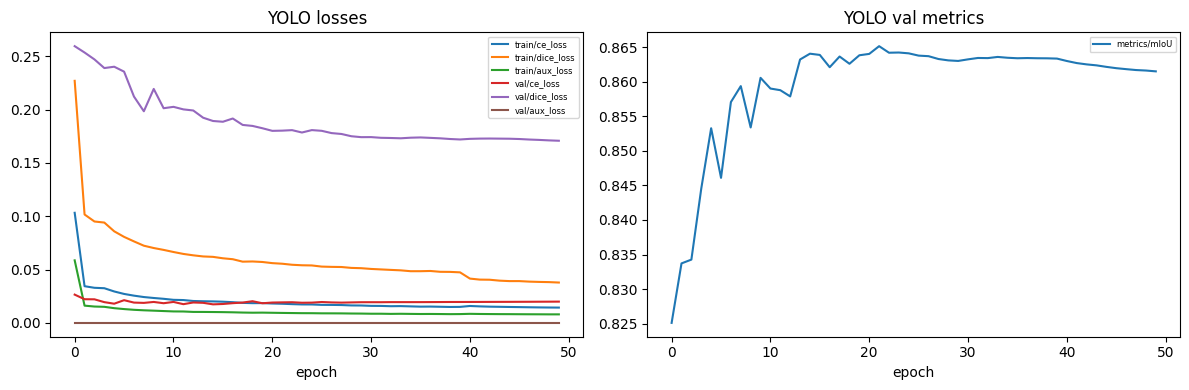

In [5]:
# per-epoch curves from Ultralytics results.csv (Task E requirement)
csvs = list((WORK/"yolo_runs").rglob("results.csv")) or [Path(p) for p in glob.glob("/kaggle/input/**/lits_sem/results.csv", recursive=True)]
if csvs:
    df = pd.read_csv(csvs[0]); df.columns = [c.strip() for c in df.columns]
    loss_cols = [c for c in df.columns if "loss" in c.lower()]
    miou_cols = [c for c in df.columns if "miou" in c.lower() or ("iou" in c.lower() and "metric" in c.lower())]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for c in loss_cols: ax[0].plot(df[c], label=c)
    ax[0].set_title("YOLO losses"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=6)
    for c in (miou_cols or [c for c in df.columns if "metric" in c.lower()]): ax[1].plot(df[c], label=c)
    ax[1].set_title("YOLO val metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=6)
    plt.tight_layout(); plt.savefig(WORK/"yolo_curves.png", dpi=120); plt.show()
else:
    print("results.csv not found under", WORK/"yolo_runs")

## 6. Loss-free metrics (Task F) — same confusion-matrix code as NB1/NB2

In [6]:
# =====================================================================
# 6. Confusion-matrix metrics (identical to NB1/NB2)
# =====================================================================
class ConfMat:
    def __init__(self, n): self.n = n; self.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(self, pred, tgt):
        k = (tgt >= 0) & (tgt < self.n)
        idx = self.n * tgt[k].to(torch.int64) + pred[k].to(torch.int64)
        self.mat += torch.bincount(idx, minlength=self.n**2).reshape(self.n, self.n)
    def compute(self):
        m = self.mat.double(); tp = m.diag(); fp = m.sum(0)-tp; fn = m.sum(1)-tp
        iou = tp/(tp+fp+fn).clamp(min=1e-9); dice = 2*tp/(2*tp+fp+fn).clamp(min=1e-9)
        recall = tp/m.sum(1).clamp(min=1e-9)
        return {"iou": iou.tolist(), "miou": iou.mean().item(), "dice": dice.tolist(),
                "mdice": dice.mean().item(), "pixel_acc": (tp.sum()/m.sum().clamp(min=1e-9)).item(),
                "mean_pixel_acc": recall.mean().item()}

def image_iou(pred, tgt):
    ious = []
    for c in range(NUM_CLASSES):
        ti = tgt == c
        if ti.sum() == 0: continue
        pi = pred == c
        inter = (pi & ti).sum(); union = (pi | ti).sum()
        ious.append(inter/union if union else 0.0)
    return float(np.mean(ious)) if ious else 1.0

def yolo_pred(model, k):
    path = str(YROOT/"images"/"test"/f"{img_by[k].stem}.png")   # exported 2.5D PNG (matches training)
    r = model.predict(path, imgsz=IMG_SIZE, verbose=False)[0]
    d = r.semantic_mask.data
    d = d.cpu().numpy() if hasattr(d, "cpu") else np.array(d)
    d = np.squeeze(d)
    if d.shape != (IMG_SIZE, IMG_SIZE):
        d = cv2.resize(d.astype(np.uint8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return d.astype(np.uint8)
print("metrics ready")

metrics ready


  500/3158 (9s)
  1000/3158 (18s)
  1500/3158 (27s)
  2000/3158 (36s)
  2500/3158 (46s)
  3000/3158 (55s)
=== YOLOv26-sem — TEST metrics ===
     class    IoU   Dice
background 0.9949 0.9974
     liver 0.9137 0.9549
     tumor 0.3382 0.5054

mIoU 0.7489 | mean Dice 0.8193 | pixel acc 0.9934 | mean pixel acc 0.7711

--- CLINICAL METRICS (medical-grade) ---
tumor sensitivity (recall) : 0.3467   (miss rate 65.3%)
liver sensitivity (recall) : 0.9691
per-patient liver Dice     : 0.9537 +/- 0.0313  (n=19)
per-patient tumor Dice     : 0.4855 +/- 0.3201  (n=16)


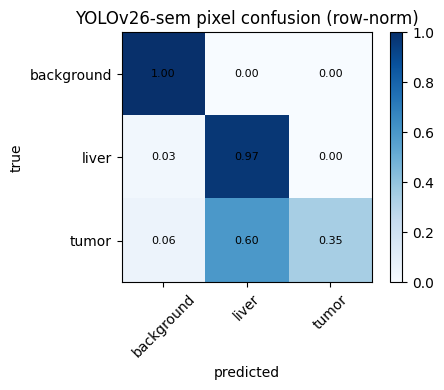

In [7]:
# =====================================================================
# 6b. Task F — predict on held-out TEST split, accumulate metrics
# =====================================================================
from collections import defaultdict
best_model = YOLO(BEST)
cmref = ConfMat(NUM_CLASSES); vol_cms = defaultdict(lambda: ConfMat(NUM_CLASSES)); per_img = []
t0 = time.time()
for j, sid in enumerate(split["test"]):
    k = tuple(int(x) for x in sid.split("_"))
    pred = yolo_pred(best_model, k); gt = combined_label(k)
    pt, gtt = torch.from_numpy(pred), torch.from_numpy(gt)
    cmref.update(pt, gtt); vol_cms[k[0]].update(pt, gtt)
    per_img.append((image_iou(pred, gt), sid))
    if (j+1) % 500 == 0: print(f"  {j+1}/{len(split['test'])} ({time.time()-t0:.0f}s)")
testm = cmref.compute()

def _dice_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fp=m[:,c].sum()-tp; fn=m[c,:].sum()-tp
    return (2*tp/(2*tp+fp+fn).clamp(min=1e-9)).item()
def _sens_c(cm, c):
    m=cm.mat.double(); tp=m[c,c]; fn=m[c,:].sum()-tp
    return (tp/(tp+fn).clamp(min=1e-9)).item()
tumor_sens=_sens_c(cmref,2); liver_sens=_sens_c(cmref,1)
liver_vd=[_dice_c(cm,1) for cm in vol_cms.values() if cm.mat[1,:].sum()>0]
tumor_vd=[_dice_c(cm,2) for cm in vol_cms.values() if cm.mat[2,:].sum()>0]
pv_liver=(float(np.mean(liver_vd)), float(np.std(liver_vd)))
pv_tumor=(float(np.mean(tumor_vd)), float(np.std(tumor_vd)))

print("=== YOLOv26-sem — TEST metrics ===")
print(pd.DataFrame({"class": CLASS_NAMES, "IoU": np.round(testm["iou"],4),
                    "Dice": np.round(testm["dice"],4)}).to_string(index=False))
print(f"\nmIoU {testm['miou']:.4f} | mean Dice {testm['mdice']:.4f} | "
      f"pixel acc {testm['pixel_acc']:.4f} | mean pixel acc {testm['mean_pixel_acc']:.4f}")
print("\n--- CLINICAL METRICS (medical-grade) ---")
print(f"tumor sensitivity (recall) : {tumor_sens:.4f}   (miss rate {1-tumor_sens:.1%})")
print(f"liver sensitivity (recall) : {liver_sens:.4f}")
print(f"per-patient liver Dice     : {pv_liver[0]:.4f} +/- {pv_liver[1]:.4f}  (n={len(liver_vd)})")
print(f"per-patient tumor Dice     : {pv_tumor[0]:.4f} +/- {pv_tumor[1]:.4f}  (n={len(tumor_vd)})")

cmn = cmref.mat.double(); cmn = (cmn/cmn.sum(1, keepdim=True).clamp(min=1e-9)).numpy()
plt.figure(figsize=(5,4)); plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45); plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("YOLOv26-sem pixel confusion (row-norm)")
for i in range(NUM_CLASSES):
    for jj in range(NUM_CLASSES): plt.text(jj, i, f"{cmn[i,jj]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(); plt.tight_layout(); plt.savefig(WORK/"yolo_confusion.png", dpi=120); plt.show()

## 7. Error analysis (Task G)
Worst test slices by per-image IoU + most-confused class pair.

**Hypotheses:** tumor is the hardest class (~0.4% of pixels, tiny lesions); YOLO's grid/anchor lineage and downsampling may miss the smallest tumors, so **tumor<->liver** confusion is expected to dominate — quantified below.

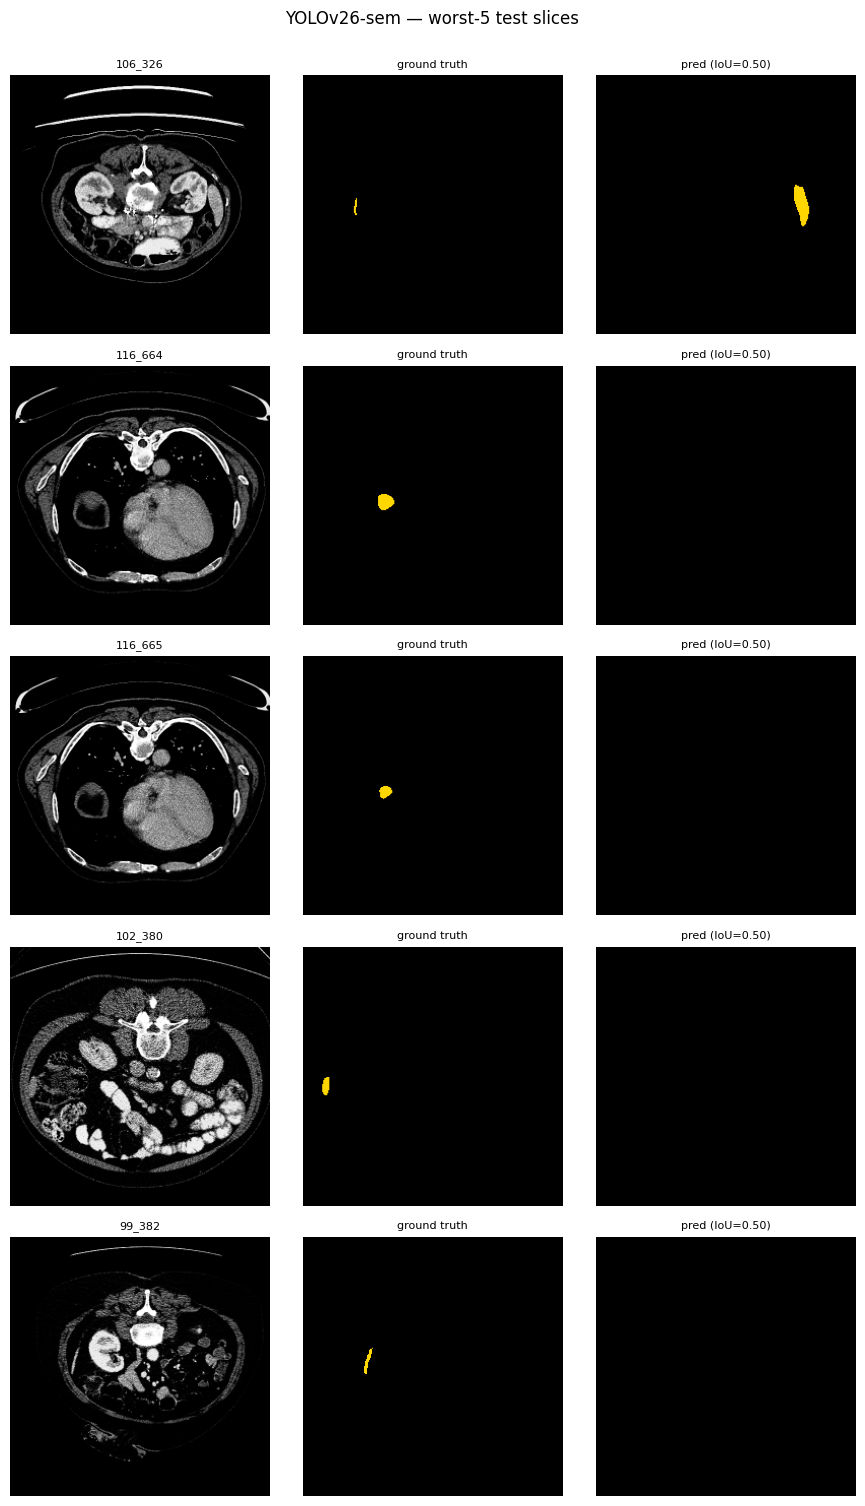

most-confused class pair: TRUE 'background' -> PRED 'liver' (506331 px)


In [8]:
# =====================================================================
# 7. Task G — worst-5 test slices (pred vs GT) + most-confused pair
# =====================================================================
per_img.sort(key=lambda t: t[0]); worst = per_img[:5]
cmap = plt.matplotlib.colors.ListedColormap(["black","gold","red"])
fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst)))
for i, (sc, sid) in enumerate(worst):
    k = tuple(int(x) for x in sid.split("_"))
    im = np.array(Image.open(img_by[k]).convert("L")); gt = combined_label(k); pr = yolo_pred(best_model, k)
    ax[i,0].imshow(im, cmap="gray"); ax[i,0].set_title(sid, fontsize=8)
    ax[i,1].imshow(gt, cmap=cmap, vmin=0, vmax=2); ax[i,1].set_title("ground truth", fontsize=8)
    ax[i,2].imshow(pr, cmap=cmap, vmin=0, vmax=2); ax[i,2].set_title(f"pred (IoU={sc:.2f})", fontsize=8)
    for j in range(3): ax[i,j].axis("off")
plt.suptitle("YOLOv26-sem — worst-5 test slices", y=1.001)
plt.tight_layout(); plt.savefig(WORK/"yolo_worst.png", dpi=120); plt.show()

off = cmref.mat.clone(); off.fill_diagonal_(0)
a, b = np.unravel_index(off.numpy().argmax(), off.shape)
print(f"most-confused class pair: TRUE '{CLASS_NAMES[a]}' -> PRED '{CLASS_NAMES[b]}' ({off[a,b].item()} px)")

In [9]:
# =====================================================================
# 7b. Append YOLO metrics to the shared results.json
# =====================================================================
res_path = WORK/"results.json"
res = {}
for rp in sorted(glob.glob("/kaggle/input/**/results.json", recursive=True)):   # MERGE all (NB1 + NB2)
    try: res.update(json.load(open(rp)))
    except Exception: pass
if res_path.exists():
    try: res.update(json.load(open(res_path)))
    except Exception: pass
res["YOLOv26-sem"] = {
    "miou": testm["miou"], "iou_per_class": testm["iou"], "dice": testm["mdice"],
    "dice_per_class": testm["dice"], "pixel_acc": testm["pixel_acc"],
    "mean_pixel_acc": testm["mean_pixel_acc"],
    "tumor_sensitivity": tumor_sens, "liver_sensitivity": liver_sens,
    "pv_liver_dice": pv_liver, "pv_tumor_dice": pv_tumor,
    "class_names": CLASS_NAMES, "config": CONFIG,
}
json.dump(res, open(res_path, "w"), indent=2)
print("results.json now has:", list(res.keys()))

results.json now has: ['DeepLabV3', 'SegFormer-B0', 'YOLOv26-sem']


## 8. Task H — Final 3-Model Comparison
Summary table, **overall + clinical bar chart, per-class IoU bar, radar chart**, side-by-side qualitative grid (same test slices, all three models + GT), **side-by-side confusion matrices, a cross-model failure scatter, a per-patient tumor-Dice box plot**, and a written verdict. DeepLabV3 and SegFormer predictions are produced by loading their best checkpoints from NB1/NB2 outputs.

In [ ]:
# =====================================================================
# 8a. Summary table (all models, all Task F metrics)
# =====================================================================
rows = []
for name, r in res.items():
    rows.append({"model": name, "mIoU": round(r["miou"],4), "mean_Dice": round(r["dice"],4),
                 "tumor_sens": round(r.get("tumor_sensitivity", float("nan")),3),
                 "pv_tumor_Dice": round((r.get("pv_tumor_dice") or [float("nan")])[0],3),
                 "pixel_acc": round(r["pixel_acc"],4), "mean_pixel_acc": round(r["mean_pixel_acc"],4),
                 "IoU_bg": round(r["iou_per_class"][0],3), "IoU_liver": round(r["iou_per_class"][1],3),
                 "IoU_tumor": round(r["iou_per_class"][2],3)})
summary = pd.DataFrame(rows).sort_values("mIoU", ascending=False).reset_index(drop=True)
summary.to_csv(WORK/"task_h_summary.csv", index=False)
display(summary)

# ---- polished summary table (figure) ----
_cols=["mIoU","mean_Dice","IoU_liver","IoU_tumor","tumor_sens","pixel_acc"]
_hdr =["mIoU","mean Dice","liver IoU","tumor IoU","tumor sens.","pixel acc"]
_cell=[[f"{summary.iloc[i][c]:.3f}" for c in _cols] for i in range(len(summary))]
fig,axt=plt.subplots(figsize=(11,0.9+0.55*len(summary))); axt.axis("off")
tb=axt.table(cellText=_cell,rowLabels=summary["model"].tolist(),colLabels=_hdr,cellLoc="center",loc="center")
tb.auto_set_font_size(False); tb.set_fontsize(11); tb.scale(1,1.8)
for j,c in enumerate(_cols):
    best=summary[c].max()
    for i in range(len(summary)):
        if abs(summary.iloc[i][c]-best)<1e-9: tb[i+1,j].set_facecolor("#d5f5e3"); tb[i+1,j].set_text_props(weight="bold")
for j in range(len(_hdr)): tb[0,j].set_facecolor("#34495e"); tb[0,j].set_text_props(color="white",weight="bold")
axt.set_title("Task H — model comparison (best per metric highlighted)",pad=12,fontweight="bold")
plt.tight_layout(); plt.savefig(WORK/"task_h_summary_table.png",dpi=140,bbox_inches="tight"); plt.show()

In [ ]:
# =====================================================================
# 8b. Bar chart — mIoU, mean Dice, and tumor sensitivity (value-labelled)
# =====================================================================
models = summary["model"].tolist(); x = np.arange(len(models)); w = 0.26
fig, ax = plt.subplots(figsize=(9,5))
for off,key,lab,c in [(-w,"mIoU","mIoU","#3498db"),(0,"mean_Dice","mean Dice","#f39c12"),(w,"tumor_sens","tumor sensitivity","#e74c3c")]:
    b = ax.bar(x+off, summary[key], w, label=lab, color=c, edgecolor="white")
    ax.bar_label(b, fmt="%.2f", padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0,1); ax.set_ylabel("score")
ax.yaxis.grid(True, ls=":", alpha=.6); ax.set_axisbelow(True)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(.5,1.12))
ax.set_title("Task H — overall & clinical performance", pad=24, fontweight="bold")
plt.tight_layout(); plt.savefig(WORK/"task_h_bars.png", dpi=140, bbox_inches="tight"); plt.show()

In [ ]:
# =====================================================================
# 8b-2. Per-class IoU across models (value-labelled)
# =====================================================================
_COLM = {"DeepLabV3":"#1f77b4","SegFormer-B0":"#ff7f0e","YOLOv26-sem":"#2ca02c"}
cls_cols = ["IoU_bg","IoU_liver","IoU_tumor"]; cls_lab = ["background","liver","tumor"]
x = np.arange(3); w = 0.26
fig, ax = plt.subplots(figsize=(9,5))
for i,(_,row) in enumerate(summary.iterrows()):
    b = ax.bar(x+(i-1)*w, [row[c] for c in cls_cols], w, label=row["model"], color=_COLM.get(row["model"]), edgecolor="white")
    ax.bar_label(b, fmt="%.2f", padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cls_lab); ax.set_ylim(0,1.05); ax.set_ylabel("IoU")
ax.yaxis.grid(True, ls=":", alpha=.6); ax.set_axisbelow(True); ax.legend(frameon=False)
ax.set_title("Task H — per-class IoU (tumor is the differentiator)", fontweight="bold")
plt.tight_layout(); plt.savefig(WORK/"task_h_perclass_iou.png", dpi=140, bbox_inches="tight"); plt.show()

In [ ]:
# =====================================================================
# 8b-3. Radar chart — multi-metric model comparison
# =====================================================================
_COLM = {"DeepLabV3":"#1f77b4","SegFormer-B0":"#ff7f0e","YOLOv26-sem":"#2ca02c"}
rmetrics = ["mIoU","mean_Dice","IoU_liver","IoU_tumor","tumor_sens"]
rlabels  = ["mIoU","mean Dice","liver IoU","tumor IoU","tumor sens."]
ang = np.linspace(0, 2*np.pi, len(rmetrics), endpoint=False).tolist(); ang += ang[:1]
fig = plt.figure(figsize=(6.8,6.4)); axr = plt.subplot(111, polar=True)
for _,row in summary.iterrows():
    vals = [float(row[m]) for m in rmetrics]; vals += vals[:1]
    axr.plot(ang, vals, lw=2, label=row["model"], color=_COLM.get(row["model"])); axr.fill(ang, vals, alpha=.10, color=_COLM.get(row["model"]))
axr.set_xticks(ang[:-1]); axr.set_xticklabels(rlabels, fontsize=11); axr.set_ylim(0,1)
axr.set_rgrids([.2,.4,.6,.8,1.0], fontsize=8)
axr.set_title("Task H — multi-metric comparison", pad=22, fontweight="bold")
axr.legend(loc="upper right", bbox_to_anchor=(1.28,1.14), frameon=False)
plt.tight_layout(); plt.savefig(WORK/"task_h_radar.png", dpi=140, bbox_inches="tight"); plt.show()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([3, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([3])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


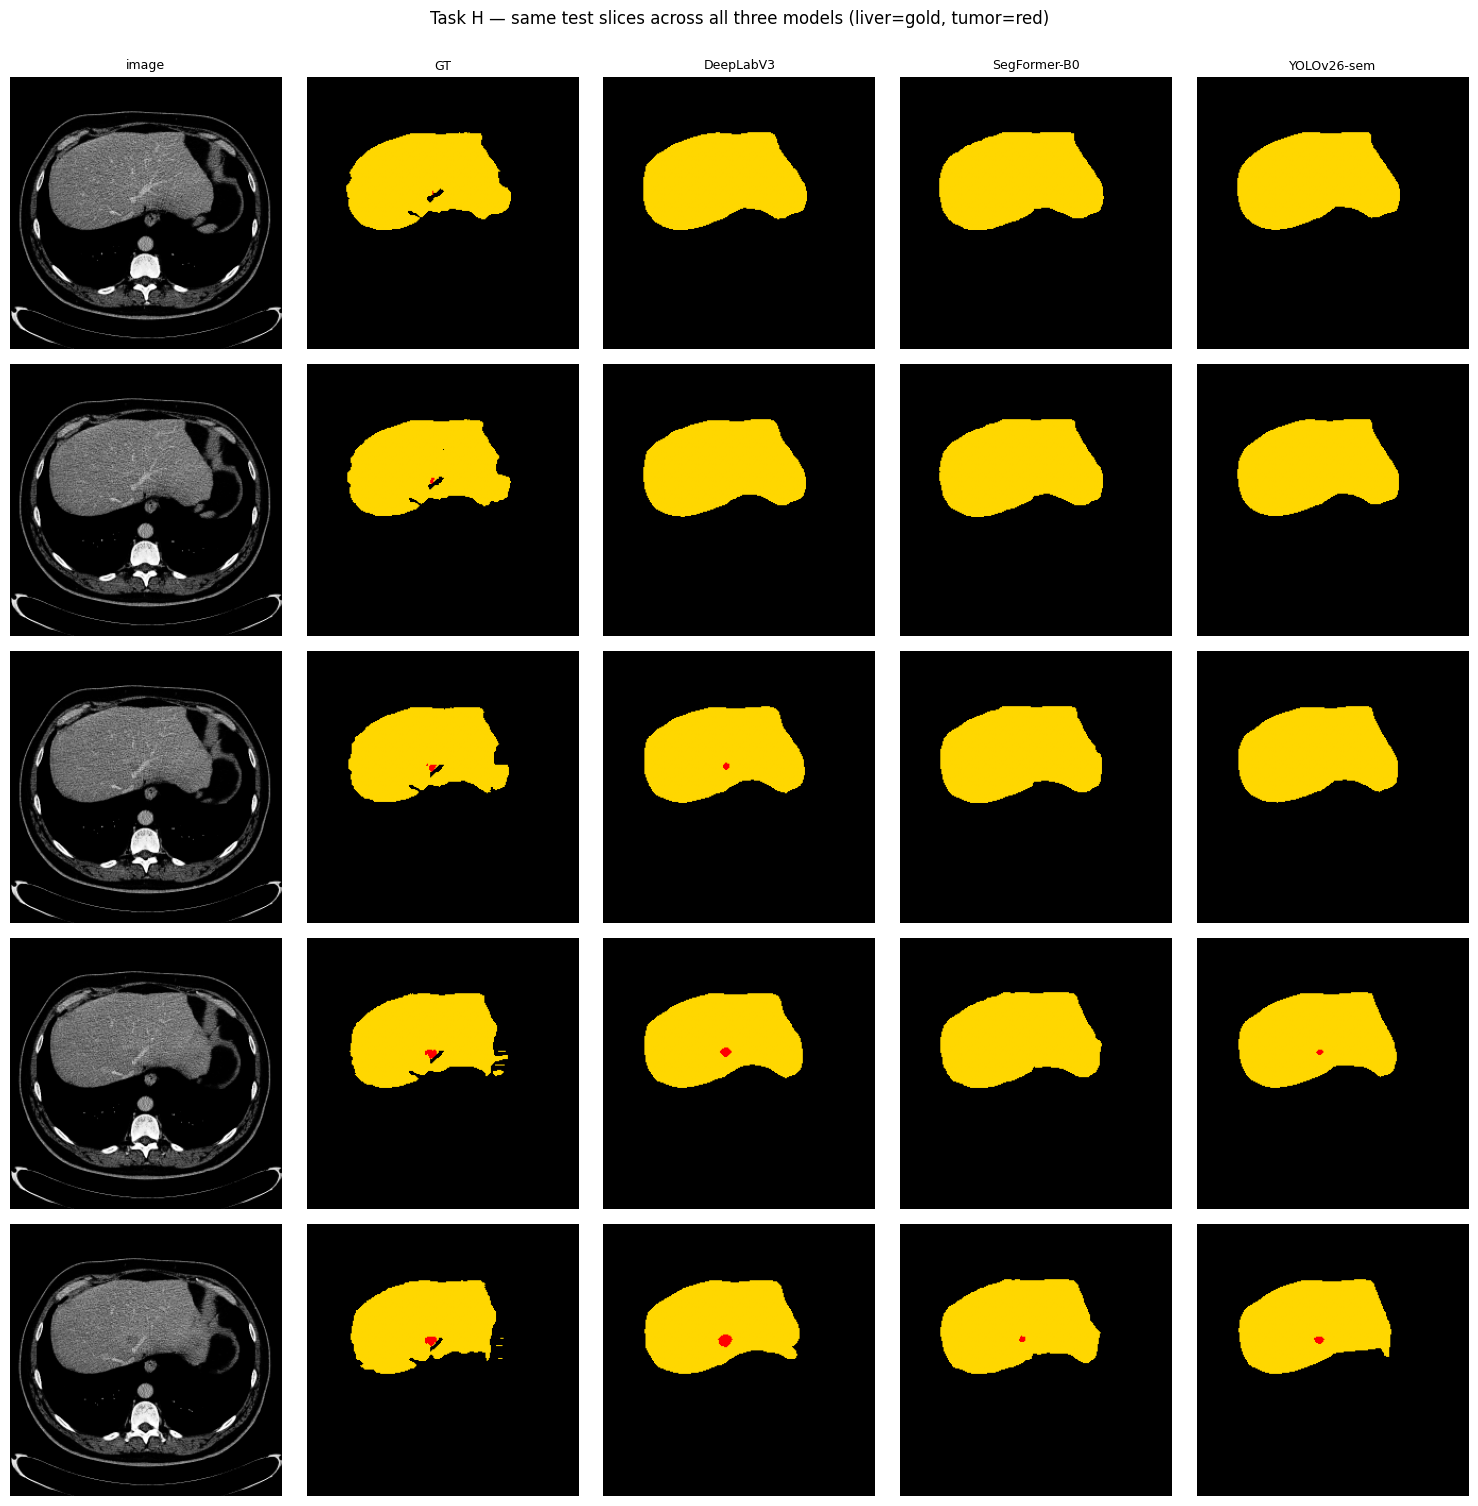

In [14]:
# =====================================================================
# 8c. Side-by-side qualitative grid: same test slices, all 3 models + GT
# =====================================================================
norm = A.Compose([A.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)), ToTensorV2()])
def _r25(vol, sl):   # 2.5D input to match how DeepLabV3/SegFormer were trained
    c = np.array(Image.open(img_by[(vol,sl)]).convert("L"))
    pv = img_by.get((vol,sl-1)); nx = img_by.get((vol,sl+1))
    p = np.array(Image.open(pv).convert("L")) if pv is not None else c
    n = np.array(Image.open(nx).convert("L")) if nx is not None else c
    return np.stack([p,c,n],-1)
def prep(k): return norm(image=_r25(*k))["image"].unsqueeze(0).to(device)

def load_deeplab():
    p = next(iter(glob.glob("/kaggle/input/**/deeplabv3_best.pt", recursive=True)), None)
    if not p: return None
    from torchvision.models.segmentation import deeplabv3_resnet50
    m = deeplabv3_resnet50(weights=None, aux_loss=True)
    m.classifier[-1] = nn.Conv2d(256, NUM_CLASSES, 1); m.aux_classifier[-1] = nn.Conv2d(256, NUM_CLASSES, 1)
    m.load_state_dict(torch.load(p, map_location=device)); return m.to(device).eval()
def load_segformer():
    p = next(iter(glob.glob("/kaggle/input/**/segformer_best.pt", recursive=True)), None)
    if not p: return None
    from transformers import SegformerForSemanticSegmentation
    m = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512", num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
    m.load_state_dict(torch.load(p, map_location=device)); return m.to(device).eval()

dl, sf = load_deeplab(), load_segformer()
def pred_dl(k):
    with torch.no_grad(): return dl(prep(k))["out"].argmax(1)[0].cpu().numpy()
def pred_sf(k):
    with torch.no_grad():
        lo = sf(pixel_values=prep(k)).logits
        return F.interpolate(lo, (IMG_SIZE,IMG_SIZE), mode="bilinear", align_corners=False).argmax(1)[0].cpu().numpy()

# pick 5 tumor-bearing test slices for a meaningful comparison
tum_sids = [s for s in split["test"] if combined_label(tuple(int(x) for x in s.split("_")))[...,].max()==2][:5]
show = tum_sids if len(tum_sids) >= 5 else split["test"][:5]
cols = ["image","GT","DeepLabV3","SegFormer-B0","YOLOv26-sem"]
fig, ax = plt.subplots(len(show), 5, figsize=(15, 3*len(show)))
for i, sid in enumerate(show):
    k = tuple(int(x) for x in sid.split("_"))
    im = np.array(Image.open(img_by[k]).convert("L")); gt = combined_label(k)
    panels = [im, gt,
              pred_dl(k) if dl else np.zeros_like(gt),
              pred_sf(k) if sf else np.zeros_like(gt),
              yolo_pred(best_model, k)]
    for j, (title, pan) in enumerate(zip(cols, panels)):
        if j == 0: ax[i,j].imshow(pan, cmap="gray")
        else: ax[i,j].imshow(pan, cmap=cmap, vmin=0, vmax=2)
        if i == 0: ax[i,j].set_title(title, fontsize=9)
        ax[i,j].axis("off")
    ax[i,0].set_ylabel(sid, fontsize=8)
plt.suptitle("Task H — same test slices across all three models (liver=gold, tumor=red)", y=1.001)
plt.tight_layout(); plt.savefig(WORK/"task_h_qualitative.png", dpi=120); plt.show()
if dl is None or sf is None:
    print("NOTE: attach NB1/NB2 outputs (deeplabv3_best.pt / segformer_best.pt) for their columns.")

### Task G/H — cross-model analysis: failure agreement, confusion, and clinical variance
Using all three models on the full test set we produce three views: **(1)** a per-image IoU **scatter** —
do the models fail on the *same* slices (points on the diagonal / high correlation → data-driven hard
cases) or *different* ones (diffuse → architecture-specific)?; **(2)** **side-by-side confusion matrices**
to compare error patterns; **(3)** a **per-patient tumor-Dice box plot** exposing inter-patient variance —
the clinically important spread that pooled metrics hide. This directly answers the PDF's Task G question.

  cross-model eval 1000/3158 (74s)
  cross-model eval 2000/3158 (147s)
  cross-model eval 3000/3158 (220s)


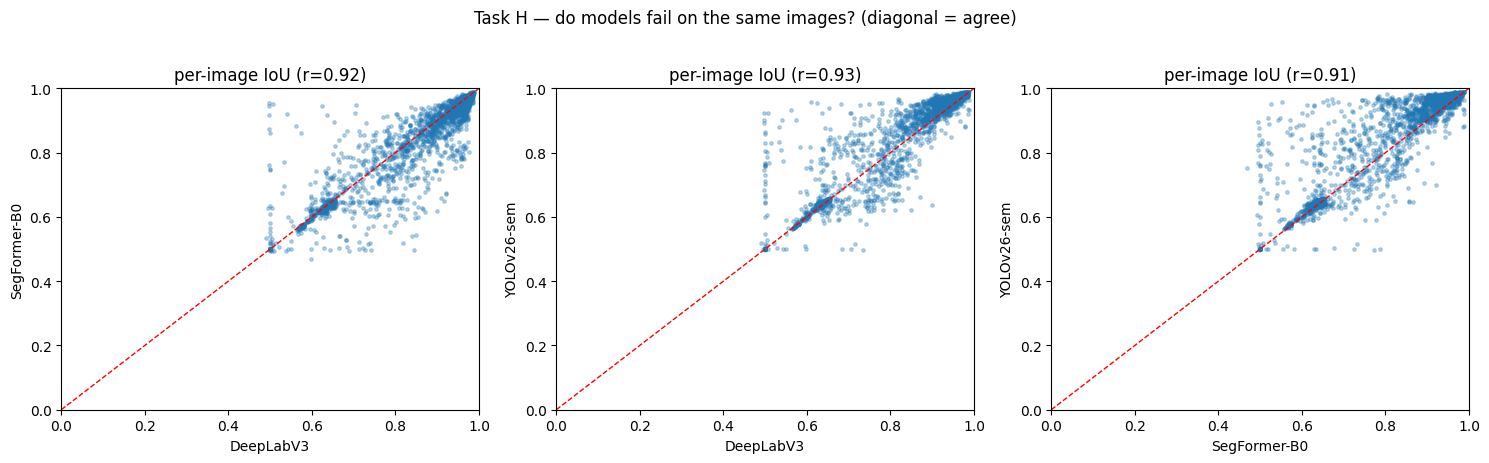

Worst-30 test-slice overlap:
  DeepLabV3 vs SegFormer-B0: 13/30 shared (Jaccard 0.28) | per-image IoU r=0.92
  DeepLabV3 vs YOLOv26-sem: 9/30 shared (Jaccard 0.18) | per-image IoU r=0.93
  SegFormer-B0 vs YOLOv26-sem: 9/30 shared (Jaccard 0.18) | per-image IoU r=0.91
  in ALL three models' worst-30: 5 slices


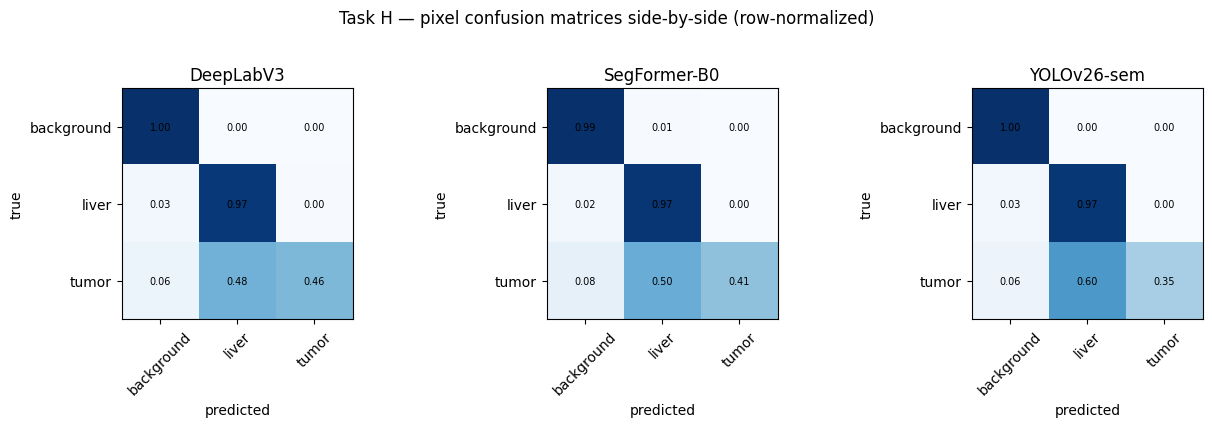

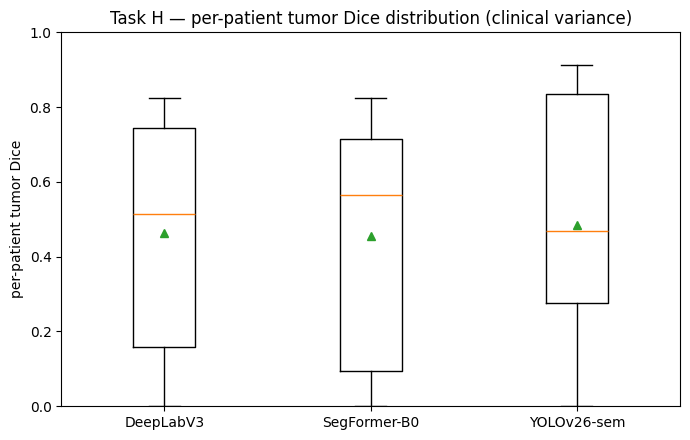

In [15]:
# =====================================================================
# 8c-2. Cross-model analysis (full test): failure agreement + confusion + per-patient variance
# =====================================================================
def img_iou(pred, gt):
    ious = []
    for c in range(NUM_CLASSES):
        ti = gt == c
        if ti.sum() == 0: continue
        pi = pred == c; inter = (pi & ti).sum(); union = (pi | ti).sum()
        ious.append(inter/union if union else 0.0)
    return float(np.mean(ious)) if ious else 1.0

_mfn = {}
if dl: _mfn["DeepLabV3"] = pred_dl
if sf: _mfn["SegFormer-B0"] = pred_sf
_mfn["YOLOv26-sem"] = lambda k: yolo_pred(best_model, k)
mcols = list(_mfn.keys())

cms = {m: np.zeros((3,3), np.int64) for m in mcols}
volcm = {m: {} for m in mcols}
per_img = {m: [] for m in mcols}
t0 = time.time()
for j, sid in enumerate(split["test"]):
    k = tuple(int(x) for x in sid.split("_")); gt = combined_label(k); v = k[0]
    for m in mcols:
        p = _mfn[m](k)
        cm = np.bincount(3*gt.reshape(-1) + p.reshape(-1), minlength=9).reshape(3,3)
        cms[m] += cm
        volcm[m][v] = volcm[m].get(v, np.zeros((3,3), np.int64)) + cm
        per_img[m].append(img_iou(p, gt))
    if (j+1) % 1000 == 0: print(f"  cross-model eval {j+1}/{len(split['test'])} ({time.time()-t0:.0f}s)")
fdf = pd.DataFrame({m: per_img[m] for m in mcols}, index=split["test"])
prs = [(a,b) for i,a in enumerate(mcols) for b in mcols[i+1:]]

# (1) per-image IoU agreement scatter
fig, ax = plt.subplots(1, len(prs), figsize=(5*len(prs), 4.5))
if len(prs) == 1: ax = [ax]
for jj,(a,b) in enumerate(prs):
    ax[jj].scatter(fdf[a], fdf[b], s=6, alpha=0.3)
    r = fdf[[a,b]].corr().iloc[0,1]
    ax[jj].plot([0,1],[0,1],"r--",lw=1); ax[jj].set_xlim(0,1); ax[jj].set_ylim(0,1)
    ax[jj].set_xlabel(a); ax[jj].set_ylabel(b); ax[jj].set_title(f"per-image IoU (r={r:.2f})")
plt.suptitle("Task H — do models fail on the same images? (diagonal = agree)", y=1.02)
plt.tight_layout(); plt.savefig(WORK/"task_h_failure_corr.png", dpi=120); plt.show()

K = 30; worst = {m: set(fdf[m].nsmallest(K).index) for m in mcols}
print(f"Worst-{K} test-slice overlap:")
for a,b in prs:
    inter = len(worst[a] & worst[b]); jac = inter/len(worst[a] | worst[b])
    print(f"  {a} vs {b}: {inter}/{K} shared (Jaccard {jac:.2f}) | per-image IoU r={fdf[[a,b]].corr().iloc[0,1]:.2f}")
if len(mcols) == 3:
    print(f"  in ALL three models' worst-{K}: {len(set.intersection(*worst.values()))} slices")

# (2) side-by-side confusion matrices (recomputed here for a unified comparison)
fig, ax = plt.subplots(1, len(mcols), figsize=(4.3*len(mcols), 4))
if len(mcols) == 1: ax = [ax]
for jj,m in enumerate(mcols):
    cn = cms[m].astype(float); cn = cn/cn.sum(1, keepdims=True).clip(min=1e-9)
    ax[jj].imshow(cn, cmap="Blues", vmin=0, vmax=1)
    ax[jj].set_xticks(range(3)); ax[jj].set_xticklabels(CLASS_NAMES, rotation=45)
    ax[jj].set_yticks(range(3)); ax[jj].set_yticklabels(CLASS_NAMES)
    ax[jj].set_title(m); ax[jj].set_xlabel("predicted"); ax[jj].set_ylabel("true")
    for aa in range(3):
        for bb in range(3): ax[jj].text(bb, aa, f"{cn[aa,bb]:.2f}", ha="center", va="center", fontsize=7)
plt.suptitle("Task H — pixel confusion matrices side-by-side (row-normalized)", y=1.04)
plt.tight_layout(); plt.savefig(WORK/"task_h_confusion_all.png", dpi=120); plt.show()

# (3) per-patient tumor Dice box plot (clinical variance across test volumes)
def _vdice(cm, c):
    tp = cm[c,c]; fp = cm[:,c].sum()-tp; fn = cm[c,:].sum()-tp
    return float(2*tp/(2*tp+fp+fn+1e-9))
box = [[_vdice(cm,2) for cm in volcm[m].values() if cm[2,:].sum() > 0] for m in mcols]
plt.figure(figsize=(7,4.5))
plt.boxplot(box, showmeans=True); plt.xticks(range(1, len(mcols)+1), mcols)
plt.ylabel("per-patient tumor Dice"); plt.ylim(0,1)
plt.title("Task H — per-patient tumor Dice distribution (clinical variance)")
plt.tight_layout(); plt.savefig(WORK/"task_h_patient_tumor_dice.png", dpi=120); plt.show()

In [ ]:
# =====================================================================
# 8d. Written verdict (data-driven)
# =====================================================================
from IPython.display import Markdown, display
best_row = summary.iloc[0]
hardest = min([("liver", summary["IoU_liver"].max()), ("tumor", summary["IoU_tumor"].max())], key=lambda t: t[1])[0]
display(Markdown(f"""### Task H — Verdict
- **Best mIoU:** **{best_row['model']}** at mIoU **{best_row['mIoU']:.3f}** (mean Dice {best_row['mean_Dice']:.3f}).
- **Hardest class across all models:** **{hardest}** — consistent with its tiny pixel share and small, low-contrast lesions.
- **Efficiency:** SegFormer-B0 (~3.7M params) and YOLOv26-sem (small) are lighter than DeepLabV3-ResNet50 (~42M); check the `train_time_min` per model in `results.json` for the speed/accuracy trade-off.
- **Deployment recommendation:** pick the model with the best **tumor IoU / sensitivity** at acceptable latency — for clinical liver-lesion screening, tumor recall matters more than background accuracy.
- **Failure modes:** the per-image IoU scatter + worst-set overlap above reveal whether the models fail on the **same** hard slices (data-driven — tiny tumors) or **different** ones (architecture-specific).

*Figures: `task_h_summary.csv`, `task_h_summary_table.png`, `task_h_bars.png`, `task_h_perclass_iou.png`, `task_h_radar.png`, `task_h_qualitative.png`, `task_h_failure_corr.png`, `task_h_confusion_all.png`, `task_h_patient_tumor_dice.png`.*"""))

## References (Academic Integrity)
- Ultralytics, *YOLO Semantic Segmentation* — https://docs.ultralytics.com/tasks/semantic/ and *Dataset format* — https://docs.ultralytics.com/datasets/semantic/
- PyTorch/torchvision *DeepLabV3*; HuggingFace *SegFormer*; Albumentations docs (cited in NB1/NB2).
All pipeline/metric code is our own; official documentation is cited where its APIs were used.